First 5 Rows
         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   Cancelled Rides by Customer Reason for cancelling by Customer  \
0    

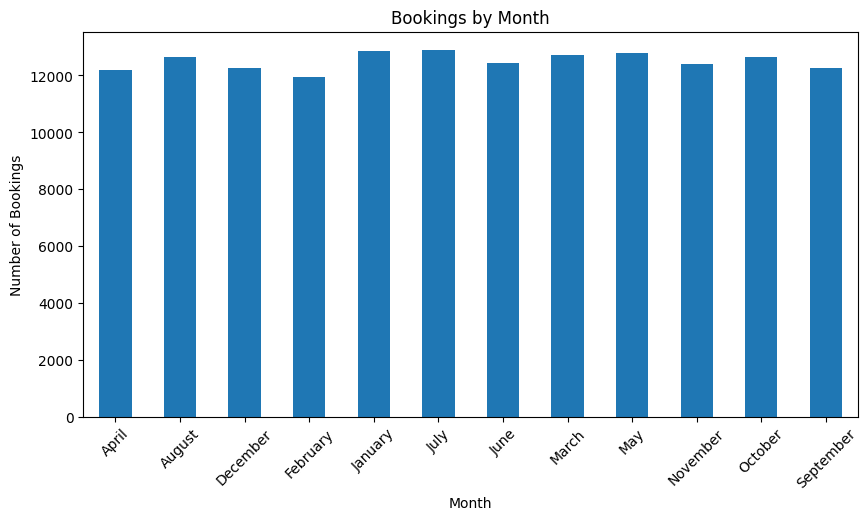

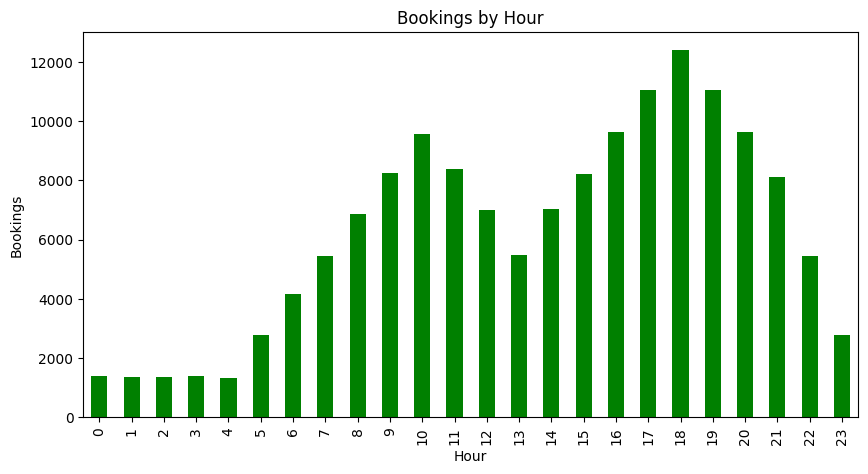

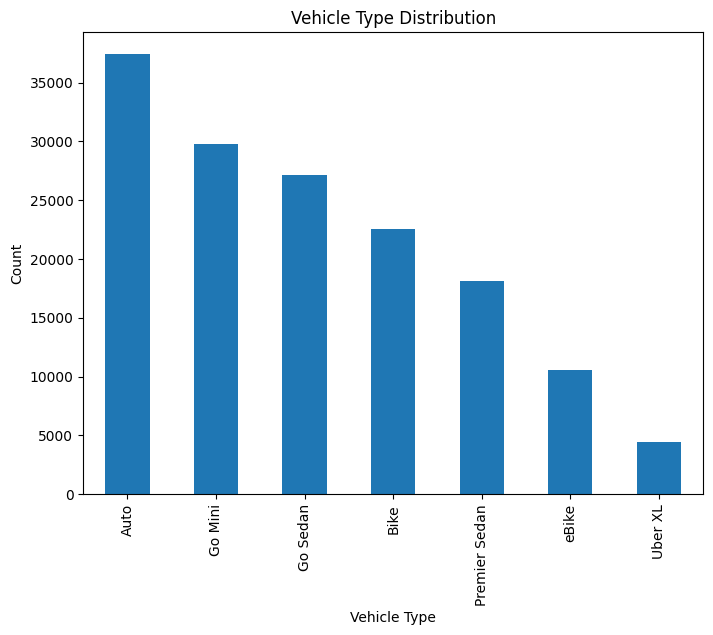

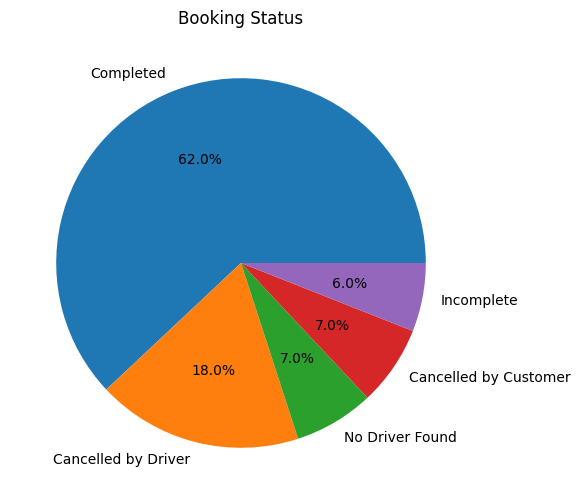

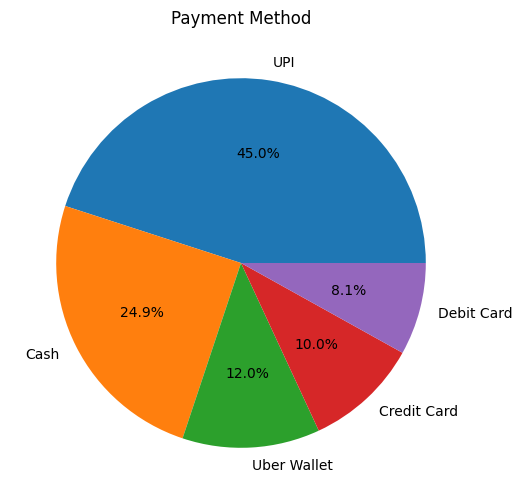

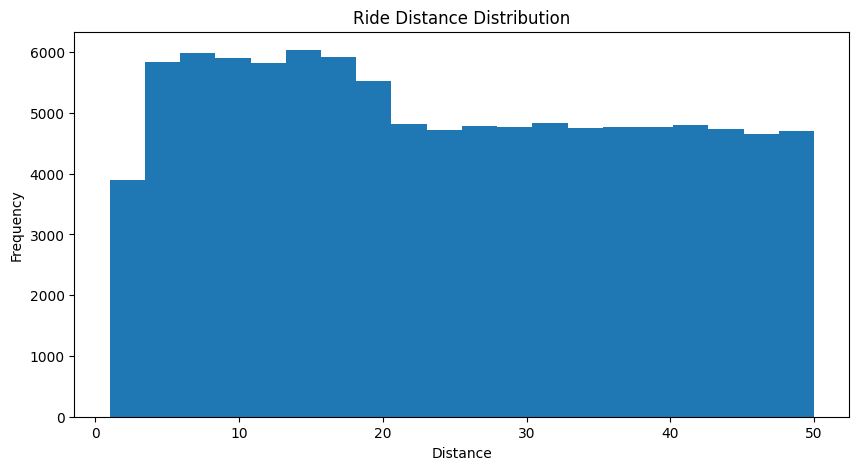

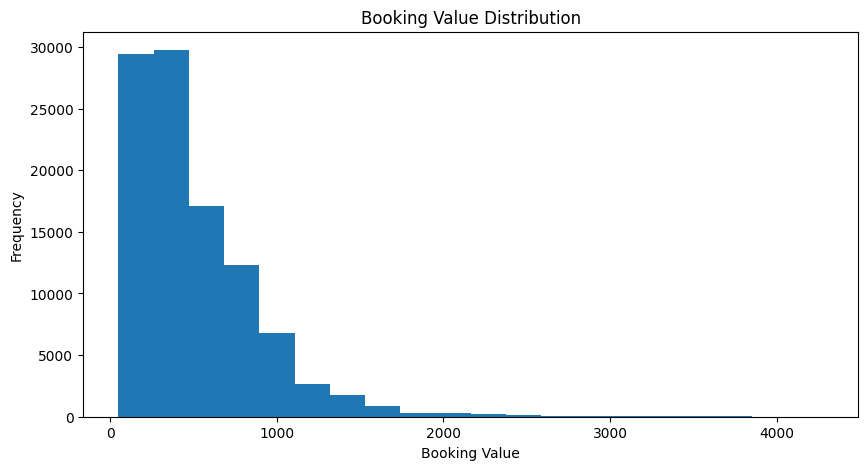

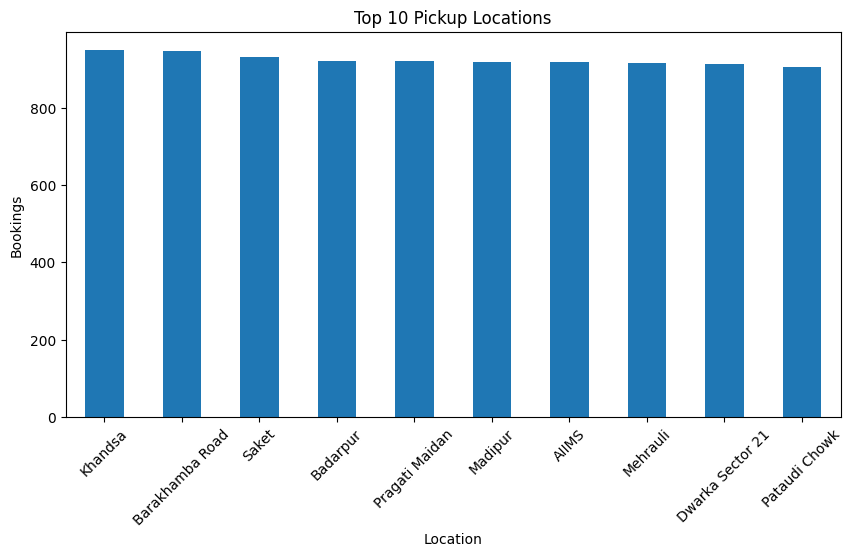

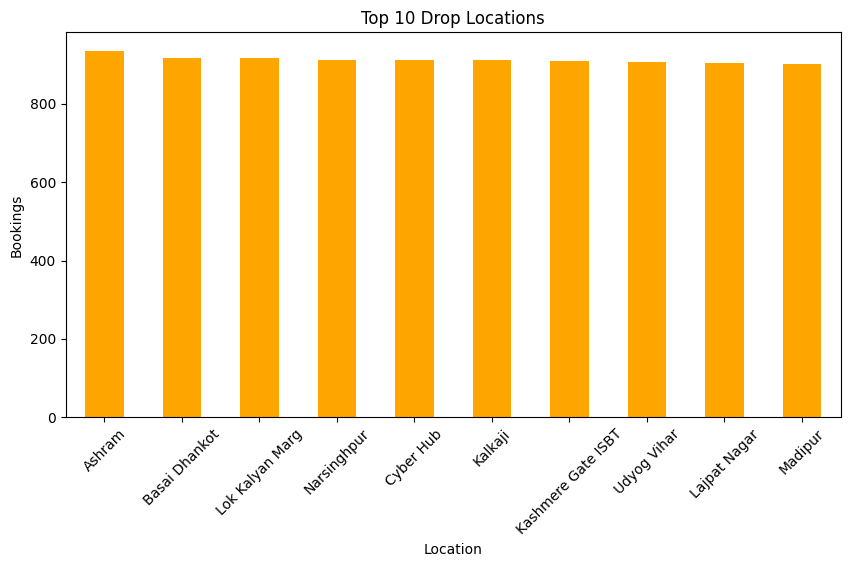


========== BUSINESS INSIGHTS ==========
Total Bookings : 150000
Average Booking Value : 508.30
Average Ride Distance : 24.64 km
Average Driver Rating : 4.23
Average Customer Rating : 4.40

Most Popular Vehicle Type:
Auto

Most Used Payment Method:
UPI

Most Common Pickup Location:
Khandsa

Most Common Drop Location:
Ashram

Most Busy Hour:
18

Most Busy Day:
Monday

Most Busy Month:
July

Project Completed Successfully!


In [1]:
# Uber Trip Data Analysis Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)

df = pd.read_csv("uber.csv")

print("="*50)
print("First 5 Rows")
print("="*50)
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary")
print(df.describe(include='all'))


# Data Cleaning

df = df.drop_duplicates()

df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day_name()

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")

# Extract Hour
df["Hour"] = df["Time"].dt.hour

print("\nData Cleaning Completed Successfully")

# Exploratory Data Analysis

print("\nBooking Status")
print(df["Booking Status"].value_counts())

print("\nVehicle Type")
print(df["Vehicle Type"].value_counts())

print("\nPayment Method")
print(df["Payment Method"].value_counts())

print("\nTop 10 Pickup Locations")
print(df["Pickup Location"].value_counts().head(10))

print("\nTop 10 Drop Locations")
print(df["Drop Location"].value_counts().head(10))

print("\nAverage Booking Value")
print(df["Booking Value"].mean())

print("\nMaximum Booking Value")
print(df["Booking Value"].max())

print("\nMinimum Booking Value")
print(df["Booking Value"].min())

print("\nAverage Ride Distance")
print(df["Ride Distance"].mean())

print("\nAverage Driver Rating")
print(df["Driver Ratings"].mean())

print("\nAverage Customer Rating")
print(df["Customer Rating"].mean())

# Monthly Bookings

monthly = df.groupby("Month").size()

plt.figure(figsize=(10,5))
monthly.plot(kind="bar")
plt.title("Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

# ------------------------------
# Bookings by Hour
# ------------------------------
hourly = df.groupby("Hour").size()

plt.figure(figsize=(10,5))
hourly.plot(kind="bar", color="green")
plt.title("Bookings by Hour")
plt.xlabel("Hour")
plt.ylabel("Bookings")
plt.show()

# ------------------------------
# Vehicle Type Distribution
# ------------------------------
plt.figure(figsize=(8,6))
df["Vehicle Type"].value_counts().plot(kind="bar")
plt.title("Vehicle Type Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.show()

# ------------------------------
# Booking Status Distribution
# ------------------------------
plt.figure(figsize=(8,6))
df["Booking Status"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Booking Status")
plt.show()

# ------------------------------
# Payment Method Distribution
# ------------------------------
plt.figure(figsize=(8,6))
df["Payment Method"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Payment Method")
plt.show()

# ------------------------------
# Ride Distance Distribution
# ------------------------------
plt.figure(figsize=(10,5))
plt.hist(df["Ride Distance"], bins=20)
plt.title("Ride Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

# ------------------------------
# Booking Value Distribution
# ------------------------------
plt.figure(figsize=(10,5))
plt.hist(df["Booking Value"], bins=20)
plt.title("Booking Value Distribution")
plt.xlabel("Booking Value")
plt.ylabel("Frequency")
plt.show()

# ------------------------------
# Top Pickup Locations
# ------------------------------
plt.figure(figsize=(10,5))
df["Pickup Location"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Pickup Locations")
plt.xlabel("Location")
plt.ylabel("Bookings")
plt.xticks(rotation=45)
plt.show()

# ------------------------------
# Top Drop Locations
# ------------------------------
plt.figure(figsize=(10,5))
df["Drop Location"].value_counts().head(10).plot(kind="bar", color="orange")
plt.title("Top 10 Drop Locations")
plt.xlabel("Location")
plt.ylabel("Bookings")
plt.xticks(rotation=45)
plt.show()

# ------------------------------
# Business Insights
# ------------------------------
print("\n========== BUSINESS INSIGHTS ==========")

print(f"Total Bookings : {len(df)}")

print(f"Average Booking Value : {df['Booking Value'].mean():.2f}")

print(f"Average Ride Distance : {df['Ride Distance'].mean():.2f} km")

print(f"Average Driver Rating : {df['Driver Ratings'].mean():.2f}")

print(f"Average Customer Rating : {df['Customer Rating'].mean():.2f}")

print("\nMost Popular Vehicle Type:")
print(df["Vehicle Type"].mode()[0])

print("\nMost Used Payment Method:")
print(df["Payment Method"].mode()[0])

print("\nMost Common Pickup Location:")
print(df["Pickup Location"].mode()[0])

print("\nMost Common Drop Location:")
print(df["Drop Location"].mode()[0])

print("\nMost Busy Hour:")
print(hourly.idxmax())

print("\nMost Busy Day:")
print(df["Day"].mode()[0])

print("\nMost Busy Month:")
print(monthly.idxmax())

print("\nProject Completed Successfully!")